# 04 -- Modele Bayesien (PyMC)
## RobynMMM -- Business Scientist MCE -- Ekimetrics

**Objectif :** estimer la distribution posterieure des coefficients MMM via MCMC (PyMC).
La difference cle avec l'OLS : on obtient non pas un point mais une **distribution** pour chaque parametre,
ce qui permet de quantifier l'incertitude sur les contributions et le ROAS.

---
### Pourquoi le bayesien apres l'OLS ?

| OLS | Bayesien |
|---|---|
| Un coefficient unique | Distribution complete du coefficient |
| IC frequentiste (asymptotique) | Intervalles de credibilite (probabilistes) |
| Pas d'incorporation d'expertise | Priors = connaissance sectorielle |
| OOH non-sig = coefficient peu fiable | OOH avec prior = estimation regularisee |

---
### Plan
1. Chargement & preparation
2. Specification des priors
3. Construction et sampling du modele PyMC
4. Diagnostics MCMC
5. Posterieurs des coefficients
6. Decomposition bayesienne avec IC
7. ROAS bayesien avec incertitude
8. Comparaison OLS vs Bayesien

## 0. Imports & chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pymc as pm
import arviz as az
import pickle
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 11,
})

# Chargement features
FEAT_PATH = Path("../data/processed/dt_features.parquet")
df = pd.read_parquet(FEAT_PATH)
df["date"] = pd.to_datetime(df["date"])

MEDIA_COLS = ["tv_S", "ooh_S", "print_S", "facebook_S", "search_S"]
MEDIA_LABELS = {"tv_S":"TV","ooh_S":"OOH","print_S":"Print","facebook_S":"Facebook","search_S":"Search"}
MEDIA_COLORS = {"tv_S":"#4E9AF1","ooh_S":"#F5C842","print_S":"#6BCB77","facebook_S":"#FF7043","search_S":"#9C5CF5"}
media_present = [c for c in MEDIA_COLS if c in df.columns]
trans_cols    = [f"{c}_transformed" for c in media_present if f"{c}_transformed" in df.columns]

Path("../outputs/figures").mkdir(parents=True, exist_ok=True)
Path("../outputs/models").mkdir(parents=True, exist_ok=True)

print(f"[OK] Dataset charge : {df.shape}")
print(f"PyMC version : {pm.__version__}")
print(f"ArviZ version : {az.__version__}")

/Users/souhail/projets-ml/RobynMMM/.venv/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


[OK] Dataset charge : (208, 20)
PyMC version : 5.28.4
ArviZ version : 0.23.4


## 1. Preparation des donnees

On normalise y et X pour que les priors soient comparables entre canaux.
La normalisation est reversee a la fin pour obtenir les contributions en EUR.

In [2]:
# Variables media transformees
X_media = df[trans_cols].values.astype(float)

# Variables de controle (tendance + saisonnalite sin/cos)
trend_norm = (np.arange(len(df)) / len(df)).reshape(-1, 1)
month = df["date"].dt.month.values
month_sin = np.sin(2 * np.pi * month / 12).reshape(-1, 1)
month_cos = np.cos(2 * np.pi * month / 12).reshape(-1, 1)

# Assemblage X
X_ctrl = np.hstack([trend_norm, month_sin, month_cos])

# Variable reponse -- normalisee par la moyenne pour stabiliser le sampling
y_raw  = df["revenue"].values.astype(float)
y_mean = y_raw.mean()
y_std  = y_raw.std()
y_norm = (y_raw - y_mean) / y_std   # centree-reduite

n_media = X_media.shape[1]
n_ctrl  = X_ctrl.shape[1]

print(f"X media shape  : {X_media.shape}  (canaux: {[MEDIA_LABELS[c] for c in media_present]})")
print(f"X controle     : {X_ctrl.shape}")
print(f"y shape        : {y_norm.shape}")
print(f"y moyenne      : {y_mean/1e6:.2f}M EUR")
print(f"y ecart-type   : {y_std/1e6:.2f}M EUR")
print()
print("Range des features media transformees (doit etre entre 0 et 1) :")
for i, col in enumerate(trans_cols):
    print(f"  {MEDIA_LABELS[media_present[i]]:<12} min={X_media[:,i].min():.3f}  max={X_media[:,i].max():.3f}  mean={X_media[:,i].mean():.3f}")

X media shape  : (208, 5)  (canaux: ['TV', 'OOH', 'Print', 'Facebook', 'Search'])
X controle     : (208, 3)
y shape        : (208,)
y moyenne      : 1.82M EUR
y ecart-type   : 0.71M EUR

Range des features media transformees (doit etre entre 0 et 1) :
  TV           min=0.000  max=0.960  mean=0.393
  OOH          min=0.000  max=0.942  mean=0.326
  Print        min=0.001  max=0.871  mean=0.447
  Facebook     min=0.000  max=0.947  mean=0.286
  Search       min=0.000  max=0.801  mean=0.327


## 2. Specification des priors

### Principe

Le prior encode notre **connaissance a priori** sur les parametres, avant de voir les donnees.
En MMM, on sait deja des choses :
- Les coefficients beta sont **positifs** (la pub genere des ventes, pas l'inverse)
- L'ordre de grandeur est connu (litterature sectorielle)
- Les canaux non-significatifs en OLS meritent quand meme un prior non-nul

### Choix des priors

```
beta_media ~ HalfNormal(sigma=1.0)   # positif par construction
alpha      ~ Normal(0, 1)            # intercept centre
beta_ctrl  ~ Normal(0, 0.5)         # controles regularises
sigma      ~ HalfNormal(0.5)        # bruit du modele
```

HalfNormal(1.0) sur les features normalisees [0,1] signifie :
- 95% de probabilite que le coefficient soit < 2 en unite normalisee
- Encourage les petites valeurs sans interdire les grandes

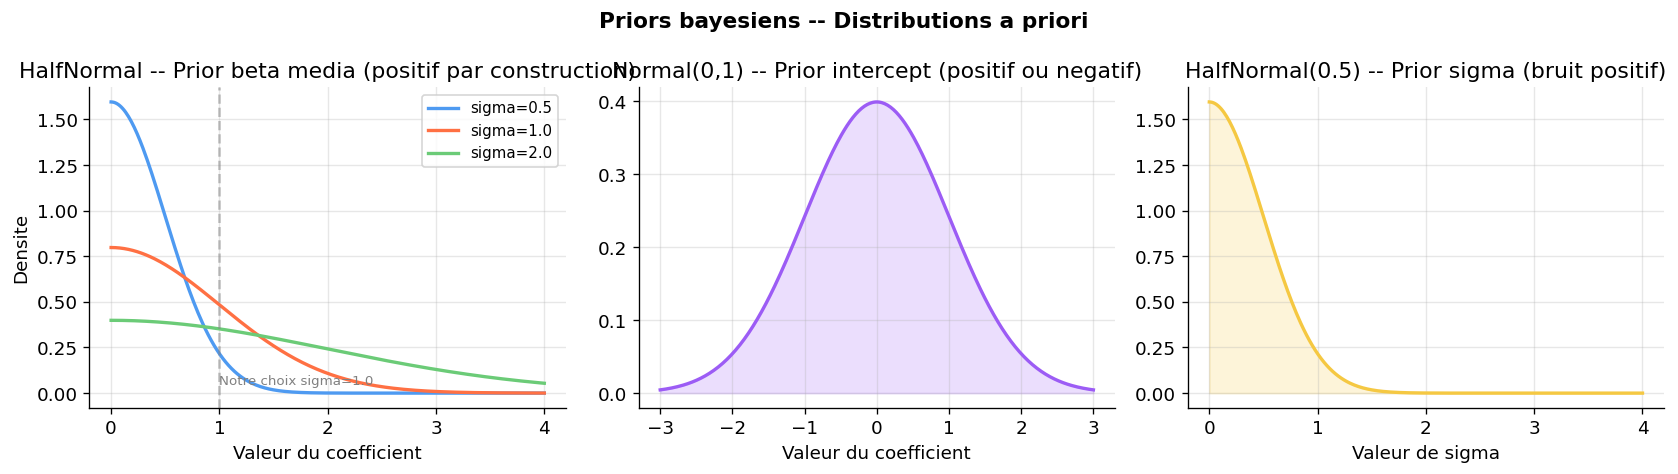

[OK] Figure sauvegardee


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Priors bayesiens -- Distributions a priori", fontsize=13, fontweight="bold")

x_pos = np.linspace(0, 4, 300)
x_all = np.linspace(-3, 3, 300)

from scipy import stats as scipy_stats

# HalfNormal pour beta media
ax = axes[0]
for sigma, color, label in [(0.5,"#4E9AF1","sigma=0.5"), (1.0,"#FF7043","sigma=1.0"), (2.0,"#6BCB77","sigma=2.0")]:
    pdf = scipy_stats.halfnorm.pdf(x_pos, scale=sigma)
    ax.plot(x_pos, pdf, color=color, linewidth=2, label=label)
ax.set_title("HalfNormal -- Prior beta media (positif par construction)")
ax.set_xlabel("Valeur du coefficient")
ax.set_ylabel("Densite")
ax.legend(fontsize=9)
ax.axvline(x=1.0, color="gray", linestyle="--", alpha=0.5)
ax.annotate("Notre choix sigma=1.0", xy=(1.0, 0.05), fontsize=8, color="gray")

# Normal pour intercept
ax2 = axes[1]
pdf2 = scipy_stats.norm.pdf(x_all, 0, 1)
ax2.plot(x_all, pdf2, color="#9C5CF5", linewidth=2)
ax2.fill_between(x_all, pdf2, alpha=0.2, color="#9C5CF5")
ax2.set_title("Normal(0,1) -- Prior intercept (positif ou negatif)")
ax2.set_xlabel("Valeur du coefficient")

# HalfNormal pour sigma
ax3 = axes[2]
pdf3 = scipy_stats.halfnorm.pdf(x_pos, scale=0.5)
ax3.plot(x_pos, pdf3, color="#F5C842", linewidth=2)
ax3.fill_between(x_pos, pdf3, alpha=0.2, color="#F5C842")
ax3.set_title("HalfNormal(0.5) -- Prior sigma (bruit positif)")
ax3.set_xlabel("Valeur de sigma")

plt.tight_layout()
plt.savefig("../outputs/figures/04_priors.png", bbox_inches="tight", dpi=150)
plt.show()
print("[OK] Figure sauvegardee")

## 3. Construction et sampling du modele PyMC

### Modele

```
revenue_norm(t) ~ Normal(mu(t), sigma)

mu(t) = alpha
      + sum_k [ beta_k * X_media_k(t) ]   # contributions media
      + sum_j [ gamma_j * X_ctrl_j(t) ]    # controles
```

NUTS (No-U-Turn Sampler) : algorithme MCMC de reference, adaptatif, efficace sur
des espaces de haute dimension. C'est l'algorithme utilise par PyMC par defaut.

In [8]:
# Construction du modele bayesien
with pm.Model() as mmm_model:

    # -- Priors media (positifs -- la pub ne detruit pas les ventes)
    beta_media = pm.HalfNormal("beta_media", sigma=1.0, shape=n_media)

    # -- Prior intercept
    alpha = pm.Normal("alpha", mu=0, sigma=1.0)

    # -- Priors controles (tendance, saisonnalite)
    beta_ctrl = pm.Normal("beta_ctrl", mu=0, sigma=0.5, shape=n_ctrl)

    # -- Prior bruit
    sigma = pm.HalfNormal("sigma", sigma=0.5)

    # -- Esperance
    mu = (alpha
          + pm.math.dot(X_media, beta_media)
          + pm.math.dot(X_ctrl,  beta_ctrl))

    # -- Vraisemblance
    likelihood = pm.Normal("y", mu=mu, sigma=sigma, observed=y_norm)

print("[OK] Modele construit")
print(f"Variables : beta_media({n_media}), alpha, beta_ctrl({n_ctrl}), sigma")
print(f"Observations : {len(y_norm)}")
print(f"Specification :")
print(f"  beta_media ~ HalfNormal(sigma=1.0)  -- {n_media} canaux")
print(f"  alpha      ~ Normal(0, 1.0)")
print(f"  beta_ctrl  ~ Normal(0, 0.5)          -- {n_ctrl} controles")
print(f"  sigma      ~ HalfNormal(sigma=0.5)")
print(f"  y          ~ Normal(mu, sigma)        -- vraisemblance")

[OK] Modele construit
Variables : beta_media(5), alpha, beta_ctrl(3), sigma
Observations : 208
Specification :
  beta_media ~ HalfNormal(sigma=1.0)  -- 5 canaux
  alpha      ~ Normal(0, 1.0)
  beta_ctrl  ~ Normal(0, 0.5)          -- 3 controles
  sigma      ~ HalfNormal(sigma=0.5)
  y          ~ Normal(mu, sigma)        -- vraisemblance


In [9]:
# Sampling MCMC avec NUTS
# draws=1000, tune=1000 = 2000 iterations dont 1000 de warm-up
# chains=2 pour evaluer la convergence (R-hat)
print("Sampling en cours... (2-5 minutes)")

with mmm_model:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        cores=1,
        target_accept=0.9,
        random_seed=42,
        progressbar=True,
        return_inferencedata=True,
    )

print("\n[OK] Sampling termine")
print(f"Posterior shape beta_media : {trace.posterior['beta_media'].shape}")
print("  (chains x draws x n_media)")

Initializing NUTS using jitter+adapt_diag...


Sampling en cours... (2-5 minutes)


Sequential sampling (2 chains in 1 job)
NUTS: [beta_media, alpha, beta_ctrl, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 5 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics



[OK] Sampling termine
Posterior shape beta_media : (2, 1000, 5)
  (chains x draws x n_media)


## 4. Diagnostics MCMC

### Indicateurs de convergence

| Indicateur | Definition | Valeur acceptable |
|---|---|---|
| **R-hat** | Rapport variance inter/intra chaines | < 1.01 |
| **ESS bulk** | Taille effective echantillon (corps) | > 400 |
| **ESS tail** | Taille effective echantillon (queues) | > 400 |
| **Divergences** | Echecs du NUTS | = 0 idealement |

In [10]:
# Summary des diagnostics
summary = az.summary(trace, var_names=["beta_media", "alpha", "sigma"])
print("=== Diagnostics MCMC ===")
print(summary.to_string())

# Verification convergence
rhat_max = summary["r_hat"].max()
ess_min  = summary["ess_bulk"].min()
diverg   = trace.sample_stats["diverging"].values.sum()

print(f"\n{'='*50}")
print(f"R-hat max     : {rhat_max:.4f}  {'[OK]' if rhat_max < 1.01 else '[ATTENTION]'}")
print(f"ESS bulk min  : {ess_min:.0f}    {'[OK]' if ess_min > 400 else '[ATTENTION]'}")
print(f"Divergences   : {diverg}       {'[OK]' if diverg == 0 else '[ATTENTION]'}")

=== Diagnostics MCMC ===
                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
beta_media[0]  0.610  0.147   0.338    0.900      0.004    0.003    1245.0     878.0    1.0
beta_media[1]  0.192  0.107   0.001    0.371      0.003    0.002    1152.0     794.0    1.0
beta_media[2]  0.173  0.110   0.000    0.359      0.003    0.002    1154.0     626.0    1.0
beta_media[3]  0.374  0.117   0.134    0.569      0.004    0.003     849.0     632.0    1.0
beta_media[4]  0.453  0.190   0.078    0.786      0.006    0.004     970.0     703.0    1.0
alpha         -0.614  0.123  -0.847   -0.387      0.004    0.003     778.0    1100.0    1.0
sigma          0.447  0.022   0.406    0.489      0.001    0.001    1466.0    1159.0    1.0

R-hat max     : 1.0000  [OK]
ESS bulk min  : 778    [OK]
Divergences   : 0       [OK]


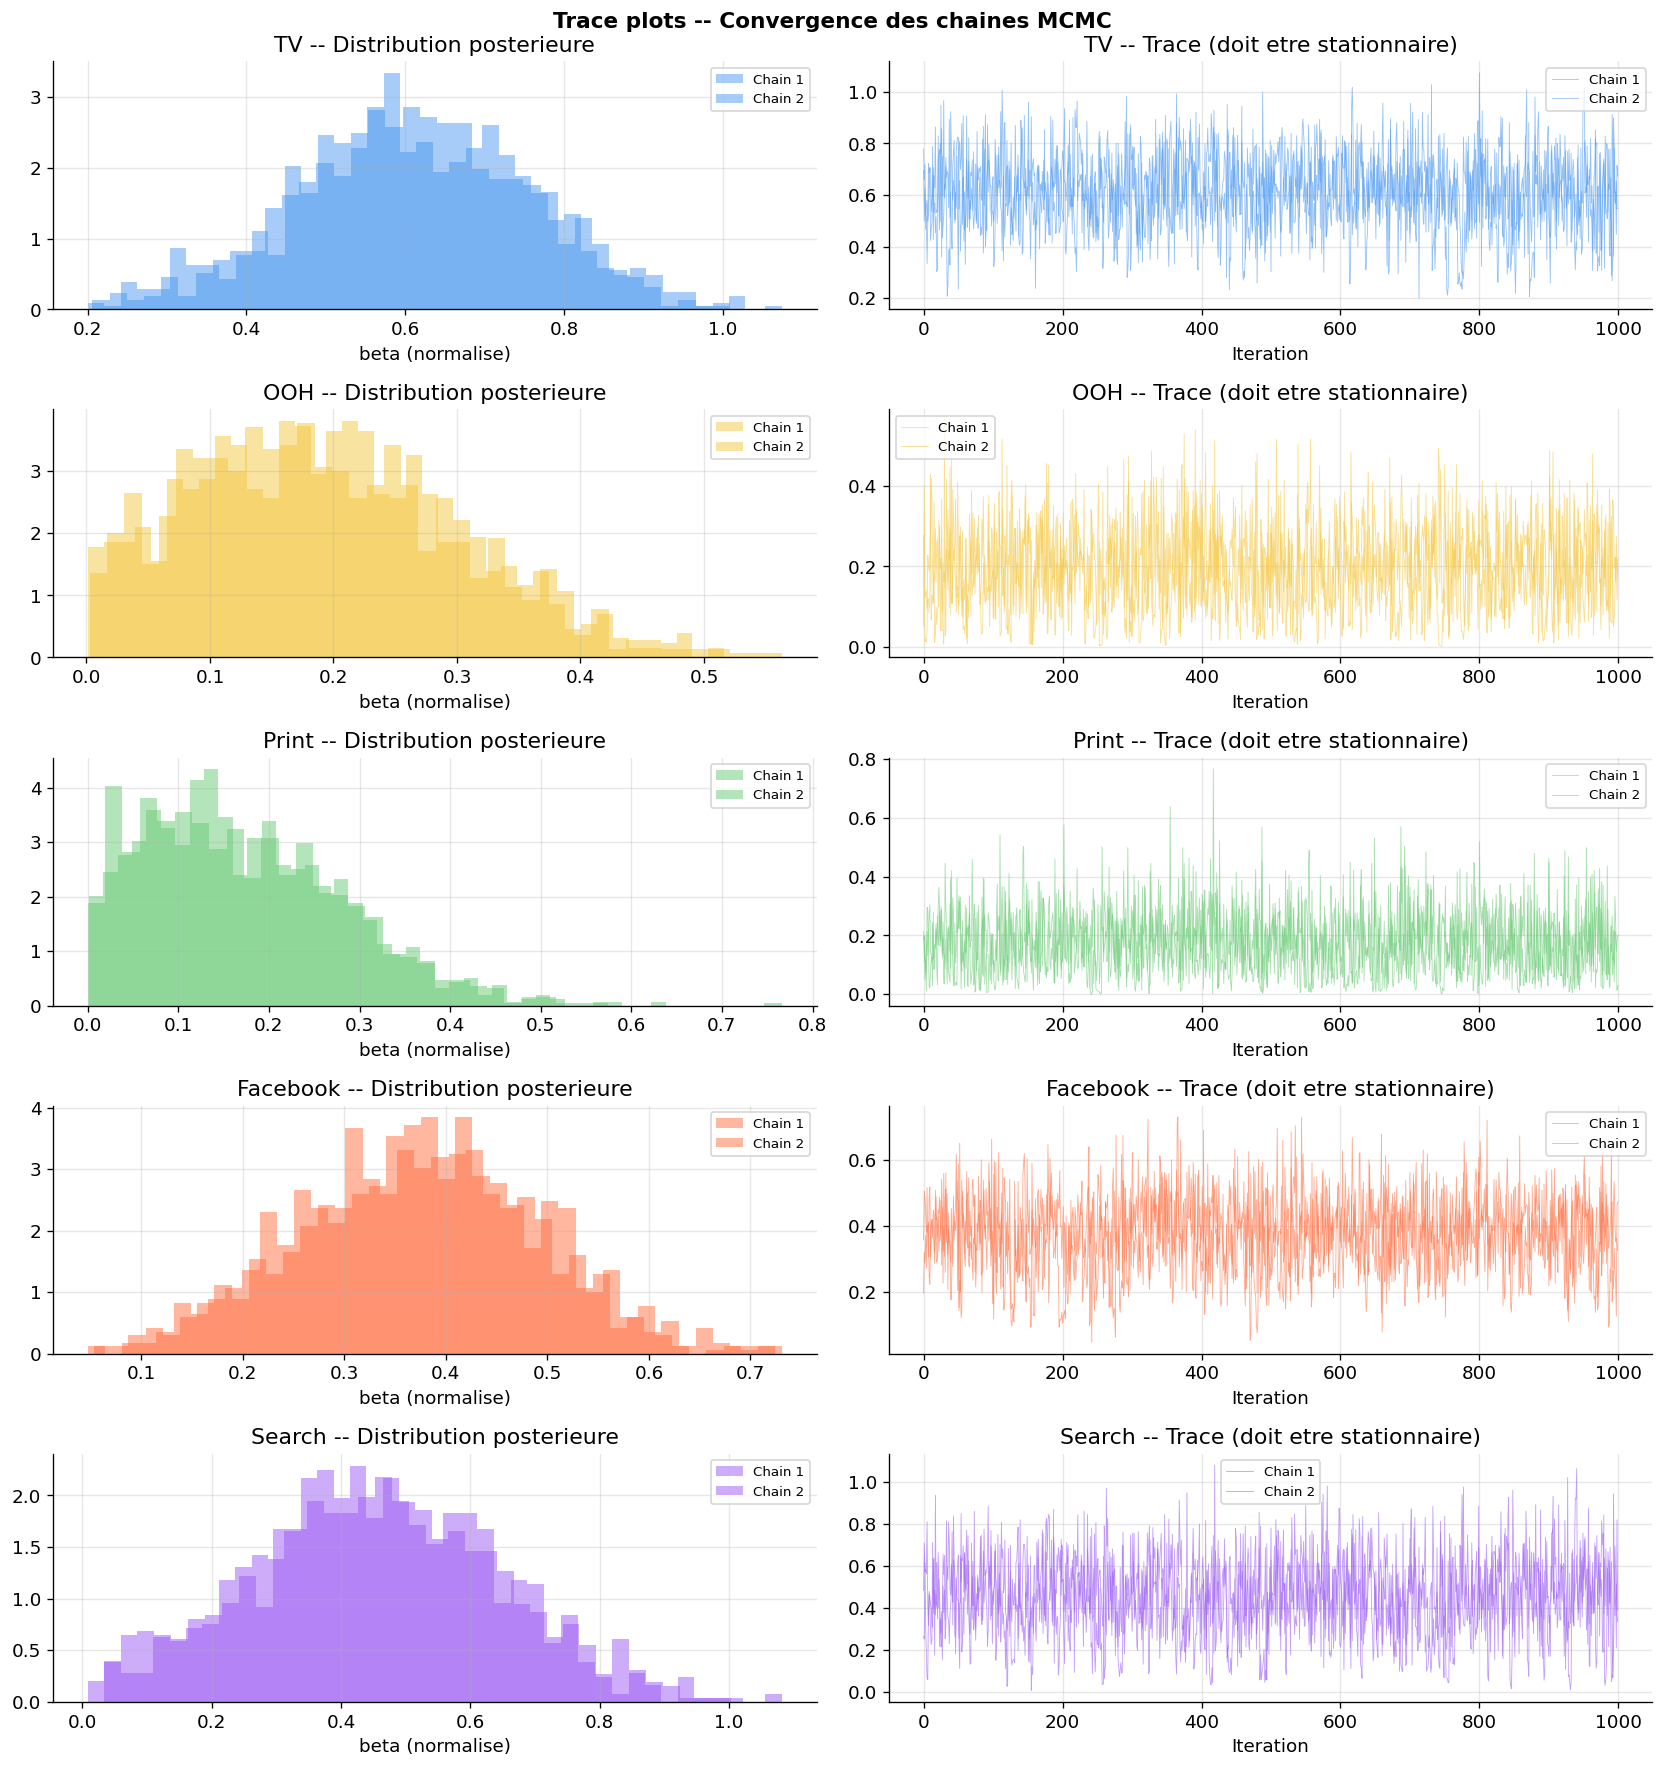

[OK] Figure sauvegardee


In [11]:
# Trace plots -- visualisation des chaines MCMC
fig, axes = plt.subplots(n_media, 2, figsize=(14, 3 * n_media))
fig.suptitle("Trace plots -- Convergence des chaines MCMC", fontsize=13, fontweight="bold")

beta_samples = trace.posterior["beta_media"].values  # (chains, draws, n_media)

for i, mc in enumerate(media_present):
    label = MEDIA_LABELS[mc]
    color = MEDIA_COLORS[mc]

    # Distribution posterieure
    ax_left = axes[i, 0]
    for chain in range(beta_samples.shape[0]):
        vals = beta_samples[chain, :, i]
        ax_left.hist(vals, bins=40, alpha=0.5, density=True, color=color,
                     label=f"Chain {chain+1}")
    ax_left.set_title(f"{label} -- Distribution posterieure")
    ax_left.set_xlabel("beta (normalise)")
    ax_left.legend(fontsize=8)

    # Trace (evolution du sampling)
    ax_right = axes[i, 1]
    for chain in range(beta_samples.shape[0]):
        vals = beta_samples[chain, :, i]
        ax_right.plot(vals, alpha=0.6, linewidth=0.5, color=color,
                      label=f"Chain {chain+1}")
    ax_right.set_title(f"{label} -- Trace (doit etre stationnaire)")
    ax_right.set_xlabel("Iteration")
    ax_right.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/figures/04_trace_plots.png", bbox_inches="tight", dpi=150)
plt.show()
print("[OK] Figure sauvegardee")

## 5. Posterieurs des coefficients

La distribution posterieure = notre croyance sur le parametre **apres** avoir vu les donnees.
Plus elle est etroite, plus le parametre est bien identifie.

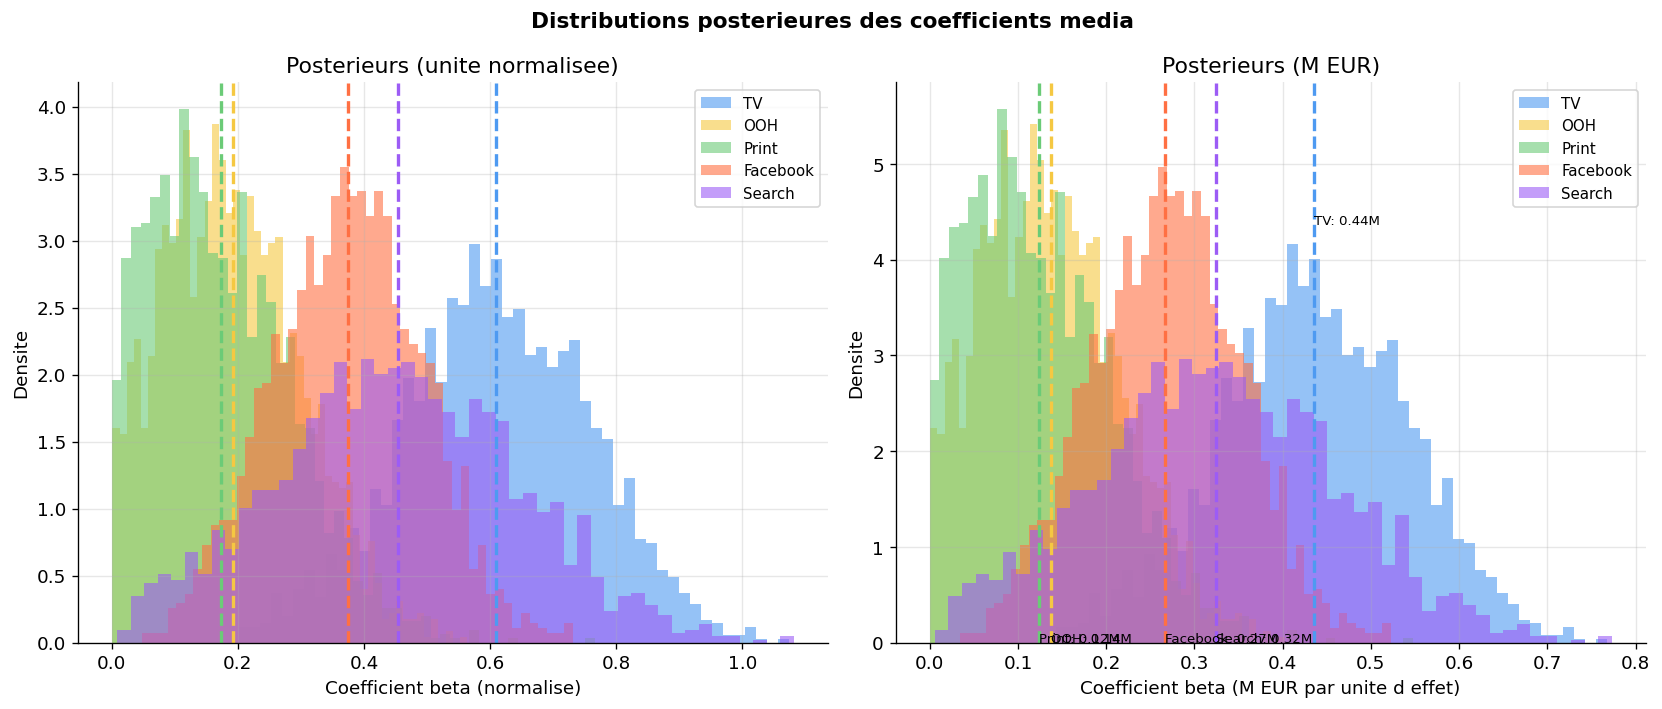


=== Posterieurs des coefficients media (M EUR) ===
Canal             Moyenne   Ecart-type    IC 94% lo    IC 94% hi  P(beta>0)
--------------------------------------------------------------
TV                  0.436        0.105        0.225        0.631     100.0%
OOH                 0.137        0.077        0.014        0.292     100.0%
Print               0.124        0.079        0.011        0.291     100.0%
Facebook            0.267        0.084        0.109        0.423     100.0%
Search              0.324        0.136        0.067        0.584     100.0%


In [12]:
# Reconvertir les coefficients normalises en EUR
# beta_EUR = beta_norm * y_std
# car y_norm = (y - y_mean) / y_std => y = y_norm * y_std + y_mean

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Distributions posterieures des coefficients media", fontsize=13, fontweight="bold")

# Posterieurs en unite normalisee
ax = axes[0]
for i, mc in enumerate(media_present):
    label = MEDIA_LABELS[mc]
    color = MEDIA_COLORS[mc]
    samples = beta_samples[:, :, i].flatten()
    ax.hist(samples, bins=50, alpha=0.6, density=True, color=color, label=label)
    ax.axvline(x=samples.mean(), color=color, linewidth=2, linestyle="--")

ax.set_xlabel("Coefficient beta (normalise)")
ax.set_ylabel("Densite")
ax.set_title("Posterieurs (unite normalisee)")
ax.legend(fontsize=9)

# Posterieurs en EUR (reconvertis)
ax2 = axes[1]
for i, mc in enumerate(media_present):
    label = MEDIA_LABELS[mc]
    color = MEDIA_COLORS[mc]
    samples_eur = beta_samples[:, :, i].flatten() * y_std / 1e6  # en M EUR
    ax2.hist(samples_eur, bins=50, alpha=0.6, density=True, color=color, label=label)
    mean_eur = samples_eur.mean()
    ax2.axvline(x=mean_eur, color=color, linewidth=2, linestyle="--")
    ax2.annotate(f"{label}: {mean_eur:.2f}M",
                xy=(mean_eur, 0), xytext=(mean_eur, ax2.get_ylim()[1] if i==0 else 0),
                fontsize=8)

ax2.set_xlabel("Coefficient beta (M EUR par unite d effet)")
ax2.set_ylabel("Densite")
ax2.set_title("Posterieurs (M EUR)")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/04_posterieurs.png", bbox_inches="tight", dpi=150)
plt.show()

# Tableau de synthese
print("\n=== Posterieurs des coefficients media (M EUR) ===")
print(f"{'Canal':<14} {'Moyenne':>10} {'Ecart-type':>12} {'IC 94% lo':>12} {'IC 94% hi':>12} {'P(beta>0)':>10}")
print("-" * 62)
for i, mc in enumerate(media_present):
    s = beta_samples[:, :, i].flatten() * y_std / 1e6
    lo, hi = np.percentile(s, [3, 97])
    prob_pos = (s > 0).mean()
    print(f"{MEDIA_LABELS[mc]:<14} {s.mean():>10.3f} {s.std():>12.3f} {lo:>12.3f} {hi:>12.3f} {prob_pos:>10.1%}")

## 6. Decomposition bayesienne avec intervalles de credibilite

Avantage cle du bayesien : chaque contribution est une **distribution**, pas un point.
On peut ainsi dire 'la contribution de TV est de 0.20M EUR avec 94% de probabilite entre 0.08M et 0.35M'.

In [13]:
# Calcul des contributions posterieures
# Pour chaque sample MCMC : contribution_k(t) = beta_k_sample * X_media_k(t)
# On obtient une distribution de contributions pour chaque semaine et chaque canal

n_samples = beta_samples.shape[0] * beta_samples.shape[1]  # chains * draws
beta_flat = beta_samples.reshape(-1, n_media)              # (n_samples, n_media)

# Contributions moyennes (point estimate)
contrib_mean = {}
contrib_lo   = {}
contrib_hi   = {}

for i, mc in enumerate(media_present):
    # Distribution des contributions semaine par semaine
    # shape : (n_samples, n_weeks)
    contrib_dist = np.outer(beta_flat[:, i], X_media[:, i]) * y_std  # en EUR

    contrib_mean[mc] = contrib_dist.mean(axis=0)
    contrib_lo[mc]   = np.percentile(contrib_dist, 3, axis=0)
    contrib_hi[mc]   = np.percentile(contrib_dist, 97, axis=0)

# Baseline
alpha_samples = trace.posterior["alpha"].values.flatten()
beta_ctrl_samples = trace.posterior["beta_ctrl"].values.reshape(-1, n_ctrl)

mu_ctrl = (np.outer(alpha_samples, np.ones(len(df)))
           + beta_ctrl_samples @ X_ctrl.T) * y_std + y_mean
baseline_mean = mu_ctrl.mean(axis=0)

print("=== Decomposition bayesienne (EUR/semaine moyen) ===")
total = y_raw.mean()
print(f"Revenue total   : {total/1e6:.3f}M EUR")
print(f"Baseline        : {baseline_mean.mean()/1e6:.3f}M EUR  ({baseline_mean.mean()/total*100:.1f}%)")
for mc in media_present:
    val = contrib_mean[mc].mean()
    pct = val / total * 100
    print(f"{MEDIA_LABELS[mc]:<14} : {val/1e6:.3f}M EUR  ({pct:.1f}%)")

=== Decomposition bayesienne (EUR/semaine moyen) ===
Revenue total   : 1.822M EUR
Baseline        : 1.369M EUR  (75.1%)
TV             : 0.171M EUR  (9.4%)
OOH            : 0.045M EUR  (2.5%)
Print          : 0.055M EUR  (3.0%)
Facebook       : 0.076M EUR  (4.2%)
Search         : 0.106M EUR  (5.8%)


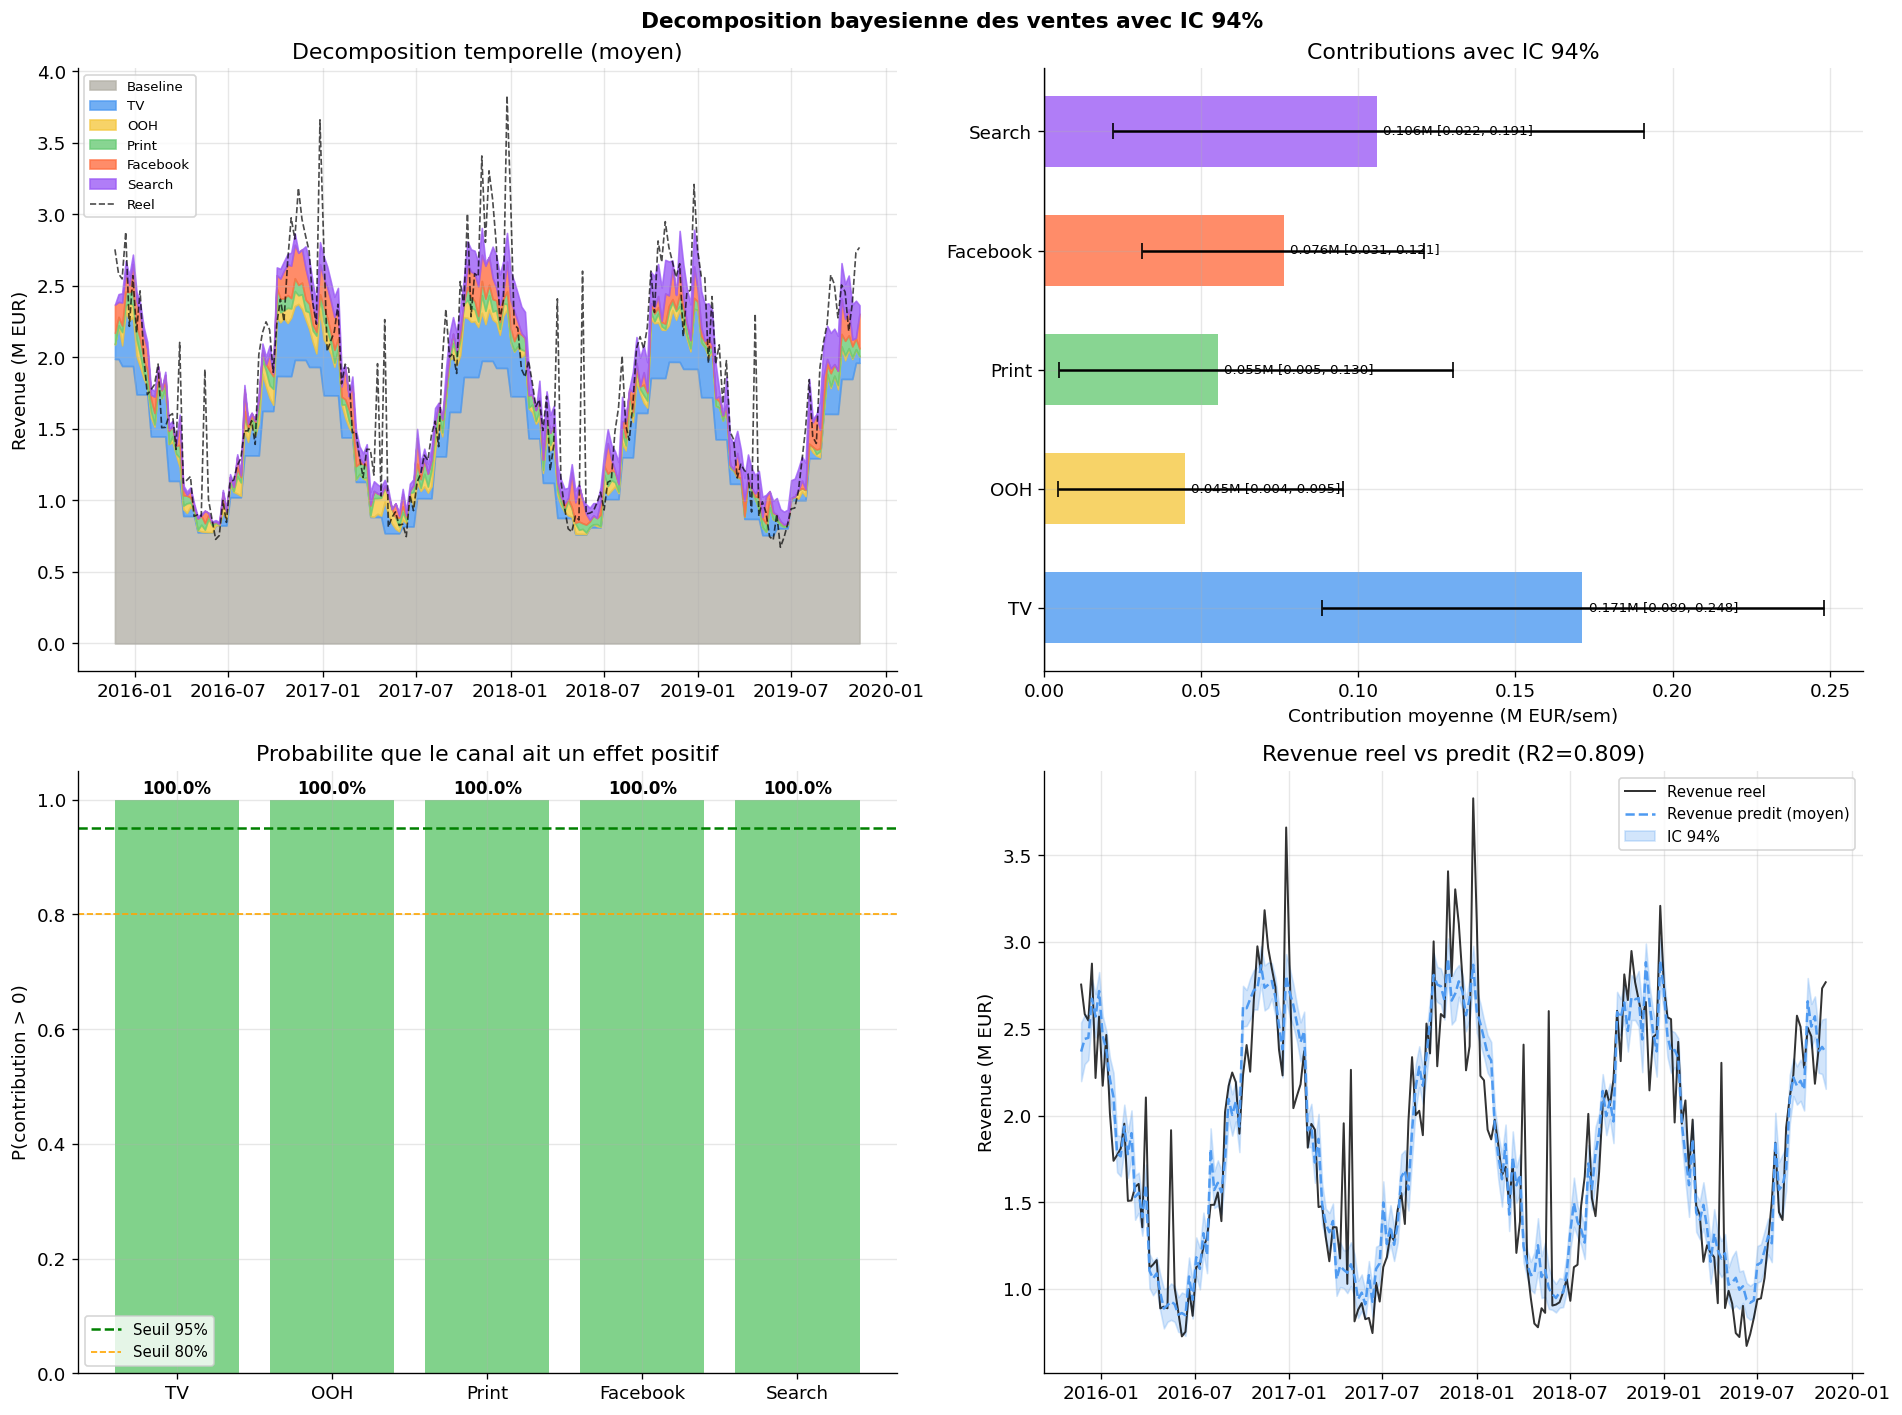

[OK] Figure sauvegardee


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Decomposition bayesienne des ventes avec IC 94%",
             fontsize=13, fontweight="bold")

# 1. Stacked area
ax = axes[0, 0]
bottom_mean = baseline_mean.copy() / 1e6
ax.fill_between(df["date"], 0, baseline_mean/1e6,
                alpha=0.8, color="#B4B2A9", label="Baseline")
for mc in media_present:
    top = bottom_mean + contrib_mean[mc]/1e6
    ax.fill_between(df["date"], bottom_mean, top,
                    alpha=0.8, color=MEDIA_COLORS[mc], label=MEDIA_LABELS[mc])
    bottom_mean = top
ax.plot(df["date"], y_raw/1e6, color="black", linewidth=1,
        linestyle="--", alpha=0.7, label="Reel")
ax.set_title("Decomposition temporelle (moyen)")
ax.set_ylabel("Revenue (M EUR)")
ax.legend(fontsize=8, loc="upper left")

# 2. IC sur les contributions par canal
ax2 = axes[0, 1]
y_pos = range(n_media)
means_plot = [contrib_mean[mc].mean()/1e6 for mc in media_present]
lo_plot    = [contrib_lo[mc].mean()/1e6   for mc in media_present]
hi_plot    = [contrib_hi[mc].mean()/1e6   for mc in media_present]
labels_p   = [MEDIA_LABELS[mc] for mc in media_present]
colors_p   = [MEDIA_COLORS[mc] for mc in media_present]

ax2.barh(y_pos, means_plot, color=colors_p, alpha=0.8, height=0.6)
ax2.errorbar(means_plot, y_pos,
             xerr=[np.array(means_plot)-np.array(lo_plot),
                   np.array(hi_plot)-np.array(means_plot)],
             fmt="none", color="black", capsize=5, linewidth=1.5)
ax2.set_yticks(list(y_pos))
ax2.set_yticklabels(labels_p)
ax2.set_xlabel("Contribution moyenne (M EUR/sem)")
ax2.set_title("Contributions avec IC 94%")
ax2.axvline(x=0, color="black", linewidth=0.8)
for i, (m, lo, hi) in enumerate(zip(means_plot, lo_plot, hi_plot)):
    txt = f"{m:.3f}M [{lo:.3f}, {hi:.3f}]"
    ax2.text(m + 0.002, i, txt, va="center", fontsize=8)

# 3. Probabilite que la contribution soit positive
ax3 = axes[1, 0]
prob_pos = []
for idx, mc in enumerate(media_present):
    contrib_dist = np.outer(beta_flat[:, idx], X_media[:, idx]) * y_std
    prob_pos.append((contrib_dist.mean(axis=1) > 0).mean())

colors_prob = ["#6BCB77" if p > 0.95 else "#F5C842" if p > 0.80 else "#FF7043"
               for p in prob_pos]
bars = ax3.bar(labels_p, prob_pos, color=colors_prob, alpha=0.85)
ax3.axhline(y=0.95, color="green", linestyle="--", linewidth=1.5, label="Seuil 95%")
ax3.axhline(y=0.80, color="orange", linestyle="--", linewidth=1, label="Seuil 80%")
ax3.set_ylabel("P(contribution > 0)")
ax3.set_title("Probabilite que le canal ait un effet positif")
ax3.legend(fontsize=9)
ax3.set_ylim(0, 1.05)
for bar, p in zip(bars, prob_pos):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{p:.1%}", ha="center", fontsize=10, fontweight="bold")

# 4. Revenue reel vs predit avec IC
ax4 = axes[1, 1]
y_pred_dist = (alpha_samples[:, None]
               + (beta_flat @ X_media.T)
               + (beta_ctrl_samples @ X_ctrl.T)) * y_std + y_mean
y_pred_mean = y_pred_dist.mean(axis=0)
y_pred_lo   = np.percentile(y_pred_dist, 3, axis=0)
y_pred_hi   = np.percentile(y_pred_dist, 97, axis=0)

ax4.plot(df["date"], y_raw/1e6, color="black", linewidth=1.2,
         label="Revenue reel", alpha=0.8)
ax4.plot(df["date"], y_pred_mean/1e6, color="#4E9AF1", linewidth=1.5,
         linestyle="--", label="Revenue predit (moyen)")
ax4.fill_between(df["date"], y_pred_lo/1e6, y_pred_hi/1e6,
                 alpha=0.25, color="#4E9AF1", label="IC 94%")
r2_bay = 1 - np.var(y_raw - y_pred_mean) / np.var(y_raw)
ax4.set_title(f"Revenue reel vs predit (R2={r2_bay:.3f})")
ax4.set_ylabel("Revenue (M EUR)")
ax4.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/04_decomposition_bayesienne.png", bbox_inches="tight", dpi=150)
plt.show()
print("[OK] Figure sauvegardee")

## 7. ROAS bayesien avec incertitude

Le ROAS bayesien donne non pas un chiffre mais une **distribution** :
`ROAS ~ contribution_posterieure / spend_total`

Cela permet de dire : 'le ROAS de Facebook est probablement entre 20x et 55x avec 94% de credibilite'.

=== ROAS Bayesien ===
Canal            Median  IC 94% lo  IC 94% hi  P(ROAS>10x)
--------------------------------------------------------
TV                 11.5x       6.0x      16.7x        71.2%
OOH                 1.0x       0.1x       2.2x         0.0%
Print              13.5x       1.3x      34.9x        64.1%
Facebook           35.8x      14.6x      56.4x        99.2%
Search             17.8x       3.7x      32.3x        84.5%


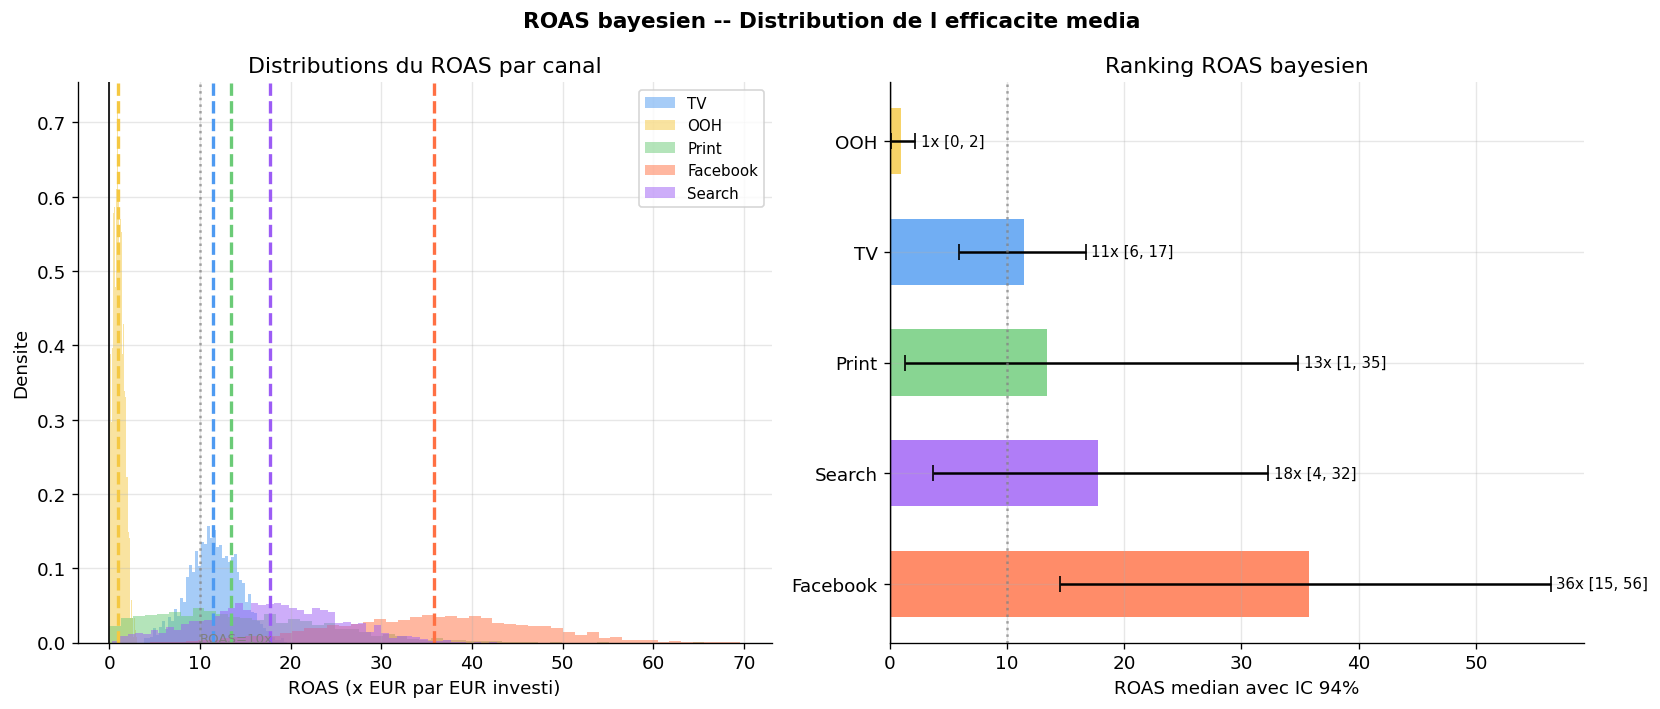

[OK] Figure sauvegardee


In [16]:
# ROAS bayesien : distribution du ROAS pour chaque canal
print("=== ROAS Bayesien ===")
print(f"{'Canal':<14} {'Median':>8} {'IC 94% lo':>10} {'IC 94% hi':>10} {'P(ROAS>10x)':>12}")
print("-" * 56)

roas_distributions = {}
for i, mc in enumerate(media_present):
    spend_total = df[mc].sum()
    if spend_total <= 0:
        continue
    # Distribution du ROAS = contrib_totale_sample / spend_total
    contrib_samples_total = (beta_flat[:, i] * X_media[:, i].sum()) * y_std
    roas_samples = contrib_samples_total / spend_total

    roas_distributions[mc] = roas_samples
    med  = np.median(roas_samples)
    lo   = np.percentile(roas_samples, 3)
    hi   = np.percentile(roas_samples, 97)
    p10x = (roas_samples > 10).mean()
    print(f"{MEDIA_LABELS[mc]:<14} {med:>8.1f}x {lo:>9.1f}x {hi:>9.1f}x {p10x:>12.1%}")

# Visualisation distributions ROAS
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("ROAS bayesien -- Distribution de l efficacite media",
             fontsize=13, fontweight="bold")

ax = axes[0]
for mc in media_present:
    if mc not in roas_distributions:
        continue
    samples = roas_distributions[mc]
    # Clip pour la visualisation (eviter les queues extremes)
    samples_clip = np.clip(samples, -5, 100)
    ax.hist(samples_clip, bins=50, alpha=0.5, density=True,
            color=MEDIA_COLORS[mc], label=MEDIA_LABELS[mc])
    med = np.median(samples)
    ax.axvline(x=med, color=MEDIA_COLORS[mc], linewidth=2, linestyle="--")

ax.axvline(x=0, color="black", linewidth=1)
ax.axvline(x=10, color="gray", linestyle=":", linewidth=1.5, alpha=0.7)
ax.annotate("ROAS=10x", xy=(10, 0), fontsize=8, color="gray")
ax.set_xlabel("ROAS (x EUR par EUR investi)")
ax.set_ylabel("Densite")
ax.set_title("Distributions du ROAS par canal")
ax.legend(fontsize=9)

# Median ROAS avec IC
ax2 = axes[1]
medians = []
lo_list = []
hi_list = []
labels_r = []
colors_r = []
for mc in media_present:
    if mc not in roas_distributions:
        continue
    s = roas_distributions[mc]
    medians.append(np.median(s))
    lo_list.append(np.percentile(s, 3))
    hi_list.append(np.percentile(s, 97))
    labels_r.append(MEDIA_LABELS[mc])
    colors_r.append(MEDIA_COLORS[mc])

# Trier par median decroissant
order = np.argsort(medians)[::-1]
medians  = [medians[i]  for i in order]
lo_list  = [lo_list[i]  for i in order]
hi_list  = [hi_list[i]  for i in order]
labels_r = [labels_r[i] for i in order]
colors_r = [colors_r[i] for i in order]

y_pos2 = range(len(medians))
ax2.barh(y_pos2, medians, color=colors_r, alpha=0.8, height=0.6)
ax2.errorbar(medians, y_pos2,
             xerr=[np.array(medians)-np.array(lo_list),
                   np.array(hi_list)-np.array(medians)],
             fmt="none", color="black", capsize=5, linewidth=1.5)
ax2.set_yticks(list(y_pos2))
ax2.set_yticklabels(labels_r)
ax2.axvline(x=0, color="black", linewidth=0.8)
ax2.axvline(x=10, color="gray", linestyle=":", linewidth=1.5, alpha=0.7)
ax2.set_xlabel("ROAS median avec IC 94%")
ax2.set_title("Ranking ROAS bayesien")
for i, (m, lo, hi) in enumerate(zip(medians, lo_list, hi_list)):
    ax2.text(max(hi, 0) + 0.5, i, f"{m:.0f}x [{lo:.0f}, {hi:.0f}]",
             va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/04_roas_bayesien.png", bbox_inches="tight", dpi=150)
plt.show()
print("[OK] Figure sauvegardee")

## 8. Comparaison OLS vs Bayesien

[OK] Resultats OLS charges


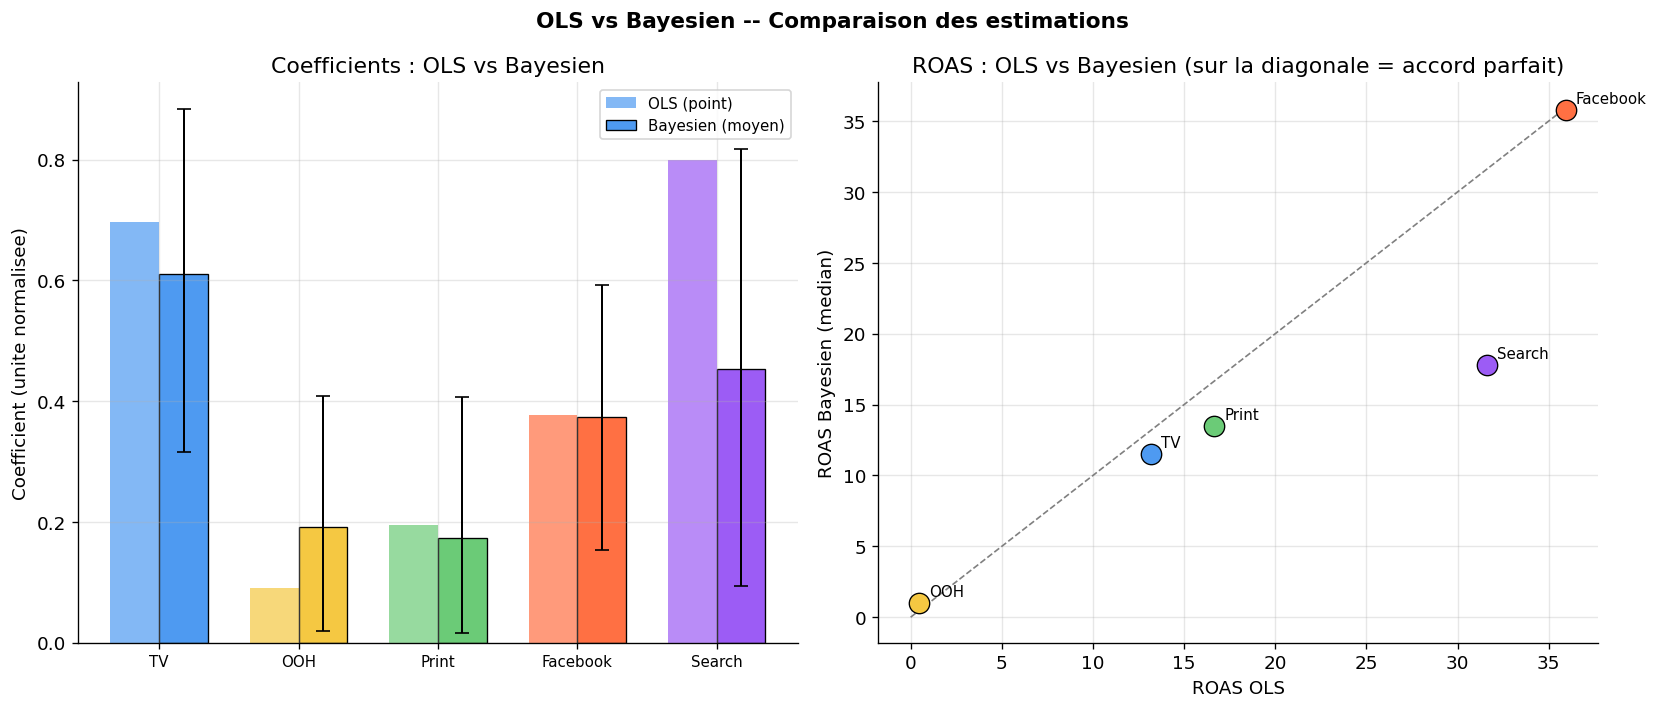

[OK] Figure sauvegardee


In [18]:
try:
    with open("../outputs/models/ols_model.pkl", "rb") as f:
        ols_data = pickle.load(f)
    ols_results = ols_data["results"]
    has_ols = True
    print("[OK] Resultats OLS charges")
except:
    has_ols = False
    print("[WARN] Fichier OLS non trouve -- comparaison ignoree")

if has_ols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("OLS vs Bayesien -- Comparaison des estimations",
                 fontsize=13, fontweight="bold")

    # Coefficients OLS vs moyennes posterieures
    ax = axes[0]
    ols_coefs = []
    bay_means = []
    bay_lo    = []
    bay_hi    = []

    for i, col in enumerate([f"{c}_transformed" for c in media_present]):
        if col in ols_results.params.index:
            ols_val = ols_results.params[col] / y_std
            bay_val = beta_flat[:, i].mean()
            bay_l   = np.percentile(beta_flat[:, i], 3)
            bay_h   = np.percentile(beta_flat[:, i], 97)
            ols_coefs.append(ols_val)
            bay_means.append(bay_val)
            bay_lo.append(bay_l)
            bay_hi.append(bay_h)

    x_pos = range(len(media_present))
    labels_c = [MEDIA_LABELS[mc] for mc in media_present]
    colors_c  = [MEDIA_COLORS[mc] for mc in media_present]
    width = 0.35

    ax.bar([x - width/2 for x in x_pos], ols_coefs, width,
           label="OLS (point)", alpha=0.7, color=colors_c)
    ax.bar([x + width/2 for x in x_pos], bay_means, width,
           label="Bayesien (moyen)", alpha=1.0, color=colors_c,
           edgecolor="black", linewidth=0.8)
    ax.errorbar([x + width/2 for x in x_pos], bay_means,
                yerr=[np.array(bay_means)-np.array(bay_lo),
                      np.array(bay_hi)-np.array(bay_means)],
                fmt="none", color="black", capsize=4, linewidth=1.2)
    ax.set_xticks(list(x_pos))
    ax.set_xticklabels(labels_c, fontsize=9)
    ax.set_ylabel("Coefficient (unite normalisee)")
    ax.set_title("Coefficients : OLS vs Bayesien")
    ax.legend(fontsize=9)

    # ROAS OLS vs ROAS bayesien
    ax2 = axes[1]
    roas_ols = ols_data["roas_df"].set_index("canal")["roas"].to_dict()

    for i, mc in enumerate(media_present):
        if mc not in roas_distributions:
            continue
        label = MEDIA_LABELS[mc]
        color = MEDIA_COLORS[mc]
        roas_bay_s = roas_distributions[mc]
        roas_bay_m = np.median(roas_bay_s)
        roas_ols_v = roas_ols.get(label, 0)

        ax2.scatter(roas_ols_v, roas_bay_m, s=150, color=color,
                    zorder=5, edgecolors="black", linewidth=0.8)
        ax2.annotate(label, (roas_ols_v, roas_bay_m),
                     textcoords="offset points", xytext=(6, 4), fontsize=9)

    max_val = max(
        max(list(roas_ols.values())),
        max([np.median(roas_distributions[mc]) for mc in roas_distributions])
    )
    ax2.plot([0, max_val], [0, max_val], color="gray", linestyle="--", linewidth=1)
    ax2.set_xlabel("ROAS OLS")
    ax2.set_ylabel("ROAS Bayesien (median)")
    ax2.set_title("ROAS : OLS vs Bayesien (sur la diagonale = accord parfait)")

    plt.tight_layout()
    plt.savefig("../outputs/figures/04_comparaison_ols_bayes.png",
                bbox_inches="tight", dpi=150)
    plt.show()
    print("[OK] Figure sauvegardee")

## 9. Sauvegarde

In [19]:
# Sauvegarder la trace et les contributions
trace.to_netcdf("../outputs/models/bayes_trace.nc")

bayes_data = {
    "trace":               trace,
    "contrib_mean":        contrib_mean,
    "contrib_lo":          contrib_lo,
    "contrib_hi":          contrib_hi,
    "roas_distributions":  roas_distributions,
    "y_mean":              y_mean,
    "y_std":               y_std,
    "media_present":       media_present,
    "trans_cols":          trans_cols,
}

with open("../outputs/models/bayes_model.pkl", "wb") as f:
    pickle.dump({k: v for k, v in bayes_data.items() if k != "trace"}, f)

print("[OK] Trace sauvegardee    : ../outputs/models/bayes_trace.nc")
print("[OK] Resultats sauvegardes: ../outputs/models/bayes_model.pkl")

[OK] Trace sauvegardee    : ../outputs/models/bayes_trace.nc
[OK] Resultats sauvegardes: ../outputs/models/bayes_model.pkl


## 10. Synthese

In [20]:
print("=" * 68)
print("  SYNTHESE -- MODELE BAYESIEN -- RobynMMM")
print("=" * 68)
print()
print("CONVERGENCE MCMC")
summary_beta = az.summary(trace, var_names=["beta_media"])
print(f"  R-hat max   : {summary_beta['r_hat'].max():.4f}")
print(f"  ESS min     : {summary_beta['ess_bulk'].min():.0f}")
print()
print("POSTERIEURS beta_media (normalises)")
for i, mc in enumerate(media_present):
    s = beta_flat[:, i]
    lo, hi = np.percentile(s, [3, 97])
    prob_pos = (s > 0).mean()
    print(f"  {MEDIA_LABELS[mc]:<12} mean={s.mean():.3f}  IC=[{lo:.3f}, {hi:.3f}]  P(>0)={prob_pos:.1%}")
print()
print("ROAS BAYESIEN (median avec IC 94%)")
for mc in media_present:
    if mc not in roas_distributions:
        continue
    s = roas_distributions[mc]
    lo, hi = np.percentile(s, [3, 97])
    print(f"  {MEDIA_LABELS[mc]:<12} {np.median(s):.1f}x  [{lo:.1f}x, {hi:.1f}x]")
print()
print("PROCHAINE ETAPE --> Notebook 05 : Decomposition complete")
print("  - Waterfall consultant")
print("  - Comparaison contributions OLS vs Bayesien")
print("=" * 68)

  SYNTHESE -- MODELE BAYESIEN -- RobynMMM

CONVERGENCE MCMC
  R-hat max   : 1.0000
  ESS min     : 849

POSTERIEURS beta_media (normalises)
  TV           mean=0.610  IC=[0.315, 0.884]  P(>0)=100.0%
  OOH          mean=0.192  IC=[0.019, 0.409]  P(>0)=100.0%
  Print        mean=0.173  IC=[0.015, 0.407]  P(>0)=100.0%
  Facebook     mean=0.374  IC=[0.153, 0.592]  P(>0)=100.0%
  Search       mean=0.453  IC=[0.094, 0.817]  P(>0)=100.0%

ROAS BAYESIEN (median avec IC 94%)
  TV           11.5x  [6.0x, 16.7x]
  OOH          1.0x  [0.1x, 2.2x]
  Print        13.5x  [1.3x, 34.9x]
  Facebook     35.8x  [14.6x, 56.4x]
  Search       17.8x  [3.7x, 32.3x]

PROCHAINE ETAPE --> Notebook 05 : Decomposition complete
  - Waterfall consultant
  - Comparaison contributions OLS vs Bayesien
